# Support Vector Machines (SVM) for Fake Review Detection

## 1. Introduction
Support Vector Machines (SVM) are powerful supervised learning models used for classification and regression. In the context of text classification, SVMs are particularly effective because they work well with high-dimensional data (like our TF-IDF vectors).

An SVM finds the optimal hyperplane that maximizes the margin between different classes. For this project, we use a **Linear SVM** (`LinearSVC`), which is optimized for large datasets and linear kernels.

---


In [1]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
DATA_PATH = '../data/processed/X_tfidf.pkl'
LABEL_PATH = '../data/processed/y.pkl'
MODEL_DIR = '../data/processed'
SEED = 42


## 2. Loading and Splitting Data
We load the precomputed TF-IDF features and labels. To ensure the model is evaluated fairly, we split the data into training (80%) and testing (20%) sets, using **stratification** to maintain the class balance.


In [2]:
X = joblib.load(DATA_PATH)
y = joblib.load(LABEL_PATH)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Data loaded and split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Data loaded and split:
Training samples: 32345
Testing samples: 8087


## 3. Hyperparameter Tuning
To maximize the performance of our SVM, we perform a grid search over the regularization parameter `C`. 
- **`C`**: Controls the trade-off between achieving a low training error and a low testing error. A smaller `C` makes the margin larger (more regularization), while a larger `C` aims for better classification of training points.

We use `GridSearchCV` with 5-fold cross-validation.


In [3]:
param_grid = {
    'C': np.logspace(-2, 1, 10)
}

print("Starting Grid Search...")
grid_search = GridSearchCV(
    LinearSVC(random_state=SEED, max_iter=2000, dual=False),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")


Starting Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': np.float64(0.46415888336127775)}
Best Cross-Validation Score: 0.8913


## 4. Evaluation
We evaluate the best model on the held-out test set to assess its generalization performance. We look at accuracy, precision, recall, and the F1-score.


In [4]:
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Original (OR)', 'Computer Generated (CG)']))


Test Accuracy: 0.894893038209472

Classification Report:

                         precision    recall  f1-score   support

          Original (OR)       0.89      0.90      0.90      4044
Computer Generated (CG)       0.90      0.89      0.89      4043

               accuracy                           0.89      8087
              macro avg       0.89      0.89      0.89      8087
           weighted avg       0.89      0.89      0.89      8087



## 5. Visualizing Results
The confusion matrix helps us understand which classes are being misclassified.


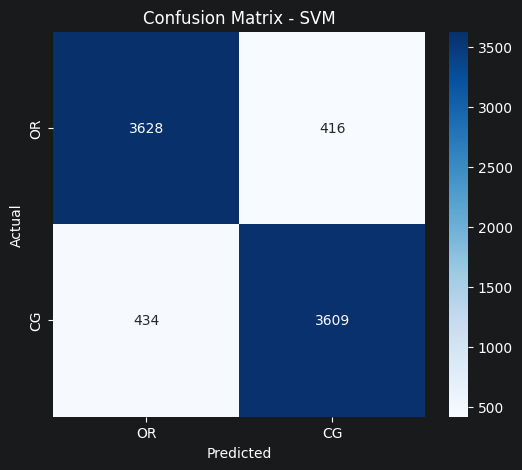

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


## 6. Saving the Model
Finally, we save the trained SVM model for use in the GUI or further inference.


In [6]:
model_filename = os.path.join(MODEL_DIR, 'svm_model.pkl')
joblib.dump(best_model, model_filename)
print(f"Model saved to: {model_filename}")


Model saved to: ../data/processed\svm_model.pkl
